# Bit por Pixel (BPP)

Bits por pixel são uma forma de representar imagens em tons de cinza. Uma imagem com $n$ bits por pixel pode ter $2^n$ tons de cinza. Supondo uma imagem capturada por tensão do pixel, você pode mapear cada tensão capturada para entrar em alguma caixinha do tom. Ou seja, se eu tiver 18 tensões diferentes, e eu tenho 4bpp (que dá 16 tons de cinza), duas daquelas tensões serão perdidas e encaixadas em algum dos outros tons de cinza, mesmo que elas seja diferente.

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

def bpp(img: np.ndarray, bits: int) -> np.typing.NDArray:
    min = np.min(img)
    max = np.max(img)
    sub = max-min
    normal = (img-min)/(sub)
    shades = 2 ** bits    
    passo = 255 / (shades - 1)
    imgFinal = (np.round(normal * (shades - 1)) * passo).astype(np.uint8)
    
    return imgFinal

## Exemplo

Suponha que a amostragem realizada por um sensor digital produziu a matriz abaixo, valores em mV (milivolts). Cada valor representa uma intensidade de brilho (tons de cinza) vinda da cena adquirida.
1. Considerando que se trate de um sistema embarcado em um hardware com uma severa restrição de memória. Quantos bits por pixel (bpp) você utilizaria para representar todos as diferentes intensidades de brilho capturadas na matriz amostrada? Discuta o caso e faça a discretização e digitalização dessa imagem, produzindo uma imagem digital de saída.
    
    
    | 6.8 | 6.8 | 6.8 | 6.8 | 6.8 | 6.8 |
    | --- | --- | --- | --- | --- | --- |
    | 1.8 | 1.8 | 1.8 | 1.8 | 1.8 | 1.8 |
    | 6.8 | 6.8 | 6.8 | 6.8 | 6.8 | 6.8 |
    | 1.8 | 1.8 | 1.8 | 1.8 | 1.8 | 1.8 |
    | 6.8 | 6.8 | 6.8 | 6.8 | 6.8 | 6.8 |
    | 1.8 | 1.8 | 1.8 | 1.8 | 1.8 | 1.8 |
2. Considere que a sua câmera possa realizar digitalizações com as seguintes profundidades de pixels (diferentes resoluções radiométricas): 1 bpp, 2 bpp, 4 bpp, 5 bpp, 8 bpp. Compare os resultados obtidos para discretização e digitalização dessas imagens em termos da resolução de detalhes das imagens. Discuta um critério de escolha, entre as alternativas de digitalização, se o sistema de processamento de imagens (posterior à captura da cena) tiver restrições de memória.
    
    
    | 6.8 | 6.87 | 6.89 | 6.89 | 6.87 | 6.8 |
    | --- | --- | --- | --- | --- | --- |
    | 5.8 | 5.87 | 5.89 | 5.89 | 5.87 | 5.8 |
    | 4.8 | 4.87 | 4.89 | 4.89 | 4.87 | 4.8 |
    | 3.8 | 3.87 | 3.89 | 3.89 | 3.87 | 3.8 |
    | 2.8 | 2.87 | 2.89 | 2.89 | 2.87 | 2.8 |
    | 1.8 | 1.87 | 1.89 | 1.89 | 1.87 | 1.8 |

### Resposta

1. Se você for bom de cálculo, você vai conseguir contar duas tensões diferentes, 1.8 e 6.8. O ideal é usarmos 1 bpp, já que $2^1=2$. Não tem motivo usar um bpp maior. O resultado será idêntico se usar um bpp maior que 1.

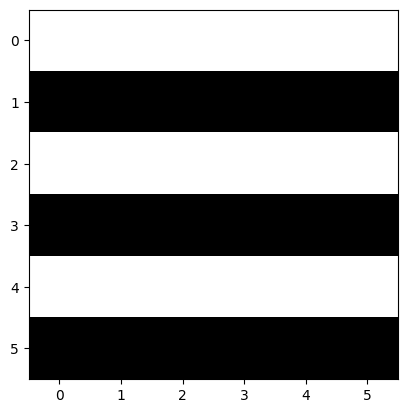

In [3]:
arr = np.array([
    [6.8,	6.8,	6.8,	6.8,	6.8,	6.8],
    [1.8,	1.8,	1.8,  1.8,  1.8,	1.8],
    [6.8,	6.8,	6.8,	6.8,	6.8,	6.8],
    [1.8,	1.8,	1.8,	1.8,	1.8,	1.8],
    [6.8,	6.8,	6.8,	6.8,	6.8,	6.8],
    [1.8,	1.8,	1.8,	1.8,	1.8,	1.8]]
)

plt.imshow(cv.cvtColor(bpp(arr,5), cv.COLOR_GRAY2BGR))

2. Vamos contar. Temos 18 tensões diferentes. Para termos a melhor precisão possível, vamos usar a menor quantidade de bits para abraçar 18 tons. Então vamos usar 5bpp, já que 2$^5$ = 32, certo? Isso levanta um problema, a diferença entre algumas medidas é bem pequena, 0.2mV. Isso pode concatenar algumas medidas, mesmo que tenham valores diferentes de outras. Então o ideal seria usar 8 bits, em que temos mais grupos e por consequência um passo maior. Dessa forma, garantimos que cada tensão tenha um tom de cinza próprio. 
Agora levanto uma pergunta, porque usaríamos um bpp menor? A resposta desse tipo de pergunta num contexto de software quase sempre é o mesmo: demanda menos do sistema. Se o sistema que irá processar essa imagem não tiver memória suficiente para 8 bpp, vale usar valores menores, como o 5 bpp. E se tiver menos ainda podemos usar 4 bpp, 2 bpp ou até 1 bpp.

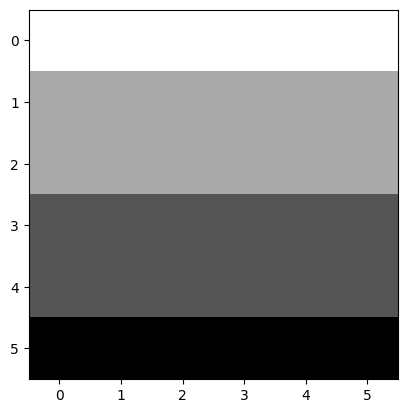

In [ ]:
arr =  np.array(
    [[6.8,	6.87,	6.89,	6.89,	6.87,	6.8],
        [5.8,	5.87,	5.89,	5.89,	5.87,	5.8],
        [4.8,	4.87,	4.89,	4.89,	4.87,	4.8],
        [3.8,	3.87,	3.89,	3.89,	3.87,	3.8],
        [2.8,	2.87,	2.89,	2.89,	2.87,	2.8],
        [1.8,	1.87,	1.89,	1.89,	1.87,	1.8]])
plt.imshow(cv.cvtColor(bpp(arr, 1), cv.COLOR_GRAY2BGR))